# Semantic Search System using the 20 Newsgroups Dataset

This project implements a lightweight semantic search system using the 20 Newsgroups dataset (~20,000 documents across 20 categories).

The system consists of the following components:

1. **Embedding & Vector Database**
   - Convert documents into vector embeddings using SentenceTransformers
   - Store embeddings in a FAISS vector database for fast similarity search

2. **Fuzzy Clustering**
   - Discover semantic topic structure in the dataset
   - Allow documents to belong to multiple clusters using fuzzy membership

3. **Semantic Cache**
   - Avoid recomputing results for similar queries
   - Detect semantically similar queries using embedding similarity

4. **FastAPI Service**
   - Provide an API interface for querying the system
   - Manage cache state and statistics

In [ ]:
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

documents = dataset.data
labels = dataset.target

print(len(documents))

18846


In [ ]:
!pip install -q sentence-transformers faiss-cpu scikit-learn scikit-fuzzy fastapi uvicorn nest-asyncio

In [ ]:
import numpy as np
import pandas as pd
import re
import string

from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer

import faiss
import skfuzzy as fuzz

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
print(documents[0])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




## Dataset

We use the 20 Newsgroups dataset, which contains approximately 20,000 newsgroup posts divided across 20 discussion topics.

The dataset contains informal text such as:

* email headers
* quoted replies
* signatures

These elements can introduce noise in semantic analysis, so basic cleaning is applied before generating embeddings.


In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
clean_docs = [clean_text(doc) for doc in documents]

print(clean_docs[0])

i am sure some bashers of pens fans are pretty confused about the lack of any kind of posts about the recent pens massacre of the devils actually i am bit puzzled too and a bit relieved however i am going to put an end to nonpittsburghers relief with a bit of praise for the pens man they are killing those devils worse than i thought jagr just showed you why he is much better than his regular season stats he is also a lot fo fun to watch in the playoffs bowman should let jagr have a lot of fun in the next couple of games since the pens are going to beat the pulp out of jersey anyway i was very disappointed not to see the islanders lose the final regular season game pens rule


## Embedding Model

To represent documents semantically, we convert each document into a vector embedding using a SentenceTransformer model.

The model used is **all-MiniLM-L6-v2**, which is:

* lightweight
* fast to compute
* effective for semantic similarity tasks

Each document is converted into a dense vector that captures its meaning.


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
embeddings = model.encode(
    clean_docs,
    batch_size=64,
    show_progress_bar=True
)

Batches:   0%|          | 0/295 [00:00<?, ?it/s]

In [ ]:
np.save("embeddings.npy", embeddings)

## Vector Database

To enable efficient semantic search, embeddings are stored in a FAISS vector index.

FAISS (Facebook AI Similarity Search) allows fast retrieval of vectors that are closest to a query embedding.

This enables the system to find documents that are semantically similar to a user query.


In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings).astype("float32"))

print("Total vectors in database:", index.ntotal)

Total vectors in database: 18846


In [ ]:
def search_documents(query, k=5):

    query_embedding = model.encode([query])

    D, I = index.search(
        np.array(query_embedding).astype("float32"), k
    )

    results = [documents[i] for i in I[0]]

    return results

In [ ]:
search_documents("space rocket launch")

["Well,  you better not get the shuttle as your launch vehicle.\n\nand most ELV's have too  far of a backlog for political messages.\n\nIf during the campaign season,  the candidates for president had\nlaunched one,  right around now we'd  be getting a launch\nfor PEROT 92.\n\nand if they had used the shuttle,  we'd be seeing launches\nfor NIXON now more then ever.",
 'To All -- I thought the net would find this amusing..\n  \nFrom the March 1993 "Aero Vision" (The newsletter for the Employees\nof McDonnell Douglas Aerospace at Huntington Beach, California).\n  \n  SPACE CLIPPERS LAUNCHED SUCCESSFULLY\n  \n  "On Monday, March 15 at noon, Quest Aerospace Education, Inc.\n  launched two DC-Y Space Clippers in the mall near the cafeteria.\n  The first rocket was launched by Dr. Bill Gaubatz, director and\n  SSTO program manager, and the second by Air Force Captain Ed\n  Spalding, who with Staff Sgt. Don Gisburne represents Air Force\n  Space Command, which was requested by SDIO to assess 

In [ ]:
data = embeddings.T

## Fuzzy Clustering

Instead of assigning each document to a single cluster, we use **fuzzy clustering**.

In fuzzy clustering, a document can belong to multiple clusters with different membership strengths.

This is useful because many documents naturally discuss multiple topics.


In [ ]:
n_clusters = 15

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data,
    n_clusters,
    2,
    error=0.005,
    maxiter=1000
)

In [ ]:
print(u.shape)

(15, 18846)


In [ ]:
def dominant_cluster(doc_id):

    return np.argmax(u[:, doc_id])

In [ ]:
def cosine_similarity(a, b):

    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [68]:
def show_cluster_examples(cluster_id, n=3):
    docs = np.where(np.argmax(u, axis=0) == cluster_id)[0][:n]

    for i in docs:
        print("\n--- Document ---\n")
        print(documents[i][:400])

In [69]:
show_cluster_examples(0)
show_cluster_examples(5)
show_cluster_examples(10)


--- Document ---

* Attention voters:
*
* I had a problem with my mailbox on the first day of voting.
* Please check the Vote Acknowlegement (ACK) at the end of this CFV.
* If your name/address is not there, please send your vote again.
* (Actually, check even if you voted after the first day)


Introduction:

	This is the third (and final) Call For Votes (CFV) for the creation
	of four OS/2 newsgroups and the rena

--- Document ---






Lets just say it is DUI here now!

 ----===== DoD #8177 = Technician(Dr. Speed) .NOT. Student =====----

--- Document ---


Is the U used in the law enforcement field from the phone which placed the
call, from the unit whose 'start secure session' button was pressed first,
or does each phone transmit its own law enforcement field?  Even assuming
one of the first two choices, the FBI is going to get a fresh N,U for its
own database about every other phone call, eventually accumulating keys for
all the phones used to co

--- Document ---



This was re

In [70]:
def show_boundary_doc(doc_id):
    membership = u[:, doc_id]
    top_clusters = membership.argsort()[-3:][::-1]

    print("Document snippet:\n")
    print(documents[doc_id][:400])

    print("\nCluster membership:")
    for c in top_clusters:
        print("Cluster", c, ":", membership[c])

In [71]:
show_boundary_doc(100)

Document snippet:


Yeah right, sorta like the Indian sub-contient, eh?

Cluster membership:
Cluster 10 : 0.06666731726744485
Cluster 6 : 0.0666671888028872
Cluster 5 : 0.066666965282228


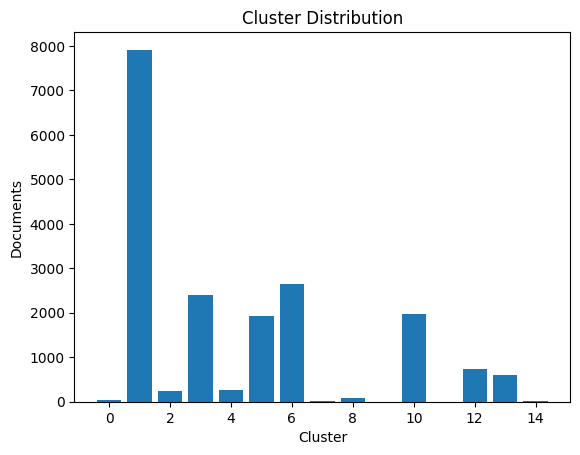

In [74]:
cluster_labels = np.argmax(u, axis=0)

cluster_sizes = np.bincount(cluster_labels)

plt.bar(range(len(cluster_sizes)), cluster_sizes)
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Documents")
plt.show()

## Semantic Cache

Traditional caching only works when queries are identical.

However, users often ask the same question using different wording.

A semantic cache solves this by:

1. Converting queries into embeddings
2. Comparing them with cached queries
3. Reusing results if the queries are semantically similar

This reduces redundant computation.


In [ ]:
class SemanticCache:

    def __init__(self, threshold=0.85):

        self.cache = []
        self.threshold = threshold

        self.hit_count = 0
        self.miss_count = 0


    def lookup(self, query_embedding):

        for entry in self.cache:

            similarity = cosine_similarity(query_embedding, entry["embedding"])

            if similarity > self.threshold:

                self.hit_count += 1

                return True, entry, similarity

        self.miss_count += 1

        return False, None, 0


    def add(self, query, embedding, result):

        self.cache.append({
            "query": query,
            "embedding": embedding,
            "result": result
        })


    def stats(self):

        total = self.hit_count + self.miss_count

        hit_rate = self.hit_count / total if total > 0 else 0

        return {
            "total_entries": len(self.cache),
            "hit_count": self.hit_count,
            "miss_count": self.miss_count,
            "hit_rate": hit_rate
        }


    def clear(self):

        self.cache = []

        self.hit_count = 0
        self.miss_count = 0

In [ ]:
cache = SemanticCache(threshold=0.85)

In [ ]:
def query_system(query):

    query_embedding = model.encode(query)

    hit, entry, similarity = cache.lookup(query_embedding)

    if hit:

        return {
            "query": query,
            "cache_hit": True,
            "matched_query": entry["query"],
            "similarity_score": similarity,
            "result": entry["result"]
        }

    results = search_documents(query)

    cache.add(query, query_embedding, results)

    return {
        "query": query,
        "cache_hit": False,
        "result": results
    }

In [ ]:
query_system("space exploration")

{'query': 'space exploration',
 'cache_hit': False,
 'result': ['We are not at the end of the Space Age, but only at the end of Its\nbeginning.\n\nThat space exploration is no longer a driver for technical innovation,\nor a focus of American cultural attention is certainly debatable; however,\ntechnical developments in other quarters will always be examined for\npossible applications in the space area and we can look forward to\nmany innovations that might enhance the capabilities and lower the\ncost of future space operations. \n\nThe Dream is Alive and Well.',
  "The AIAA San Gabriel Valley Section is sponsoring the following lecture\non Mars exploration at the Jet Propulsion Lab.  Admission is free and open to\nthe public.\n\n                           The Next Frontier:\n                    The Challenge of Mars Exploration\n\n                      DATE:     May 6, 1993\n                      TIME:     6:00PM - 8:30 PM\n                      LOCATION: Von Karman Auditorium\n       

In [ ]:
query_system("exploring space missions")

{'query': 'exploring space missions',
 'cache_hit': True,
 'matched_query': 'exploring space missions',
 'similarity_score': np.float32(1.0),
 'result': ['I know that alot of how people think and act in a long distance space project\nwould be much like old tiem explorers, sailors, hunters and such who spent alot\nof time alone, isolated, and alone or in minimal surroundings and sopcial\ncontacts.. Such as the old arctic and antarctic expeditions and such..\n\nI vote for a later on sci.space.medicine or similar newsgroup fro the\ndiscussion of long term missions into space and there affects on humans and\nsuch..',
  "The AIAA San Gabriel Valley Section is sponsoring the following lecture\non Mars exploration at the Jet Propulsion Lab.  Admission is free and open to\nthe public.\n\n                           The Next Frontier:\n                    The Challenge of Mars Exploration\n\n                      DATE:     May 6, 1993\n                      TIME:     6:00PM - 8:30 PM\n          

In [ ]:
cache.stats()

{'total_entries': 2,
 'hit_count': 1,
 'miss_count': 2,
 'hit_rate': 0.3333333333333333}

In [ ]:
cache.clear()

In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok

<frozen posixpath>:82: RuntimeWarning: coroutine 'Server.serve' was never awaited


## FastAPI Service

The system exposes a FastAPI service that allows users to query the semantic search system.

Endpoints include:

POST /query – performs semantic search and checks cache
GET /cache/stats – returns cache statistics
DELETE /cache – clears the cache


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import nest_asyncio
import uvicorn

nest_asyncio.apply()

In [ ]:
app = FastAPI()

In [ ]:
class QueryRequest(BaseModel):
    query: str

In [ ]:
@app.post("/query")
def search_api(request: QueryRequest):

    query = request.query

    query_embedding = model.encode(query)

    hit, entry, similarity = cache.lookup(query_embedding)

    if hit:

        return {
            "query": query,
            "cache_hit": True,
            "matched_query": entry["query"],
            "similarity_score": float(similarity),
            "result": entry["result"]
        }

    results = search_documents(query)

    cache.add(query, query_embedding, results)

    return {
        "query": query,
        "cache_hit": False,
        "result": results
    }

In [ ]:
@app.get("/cache/stats")
def cache_stats():

    return cache.stats()

In [ ]:
@app.delete("/cache")
def clear_cache():

    cache.clear()

    return {"message": "Cache cleared"}

In [ ]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
import uvicorn
import threading

def run_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_api)
thread.start()

INFO:     Started server process [371]
INFO:     Waiting for application startup.


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3AdSJG7e86gd2fFii9A2JEOc3X4_TN4Me5zARfTbfQWPD8B")

public_url = ngrok.connect(8000)

print("Public API URL:", public_url)

Public API URL: NgrokTunnel: "https://shavonda-untalented-nontrigonometrically.ngrok-free.dev" -> "http://localhost:8000"


## Conclusion

This project demonstrates a lightweight semantic search system using vector embeddings, fuzzy clustering, and semantic caching.

The system efficiently retrieves semantically relevant documents while avoiding repeated computations for similar queries.

Future improvements could include more advanced embeddings, scalable vector databases, and distributed caching.
